[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/beaglecat/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/beaglecat/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/beaglecat/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/beaglecat/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/beaglecat/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


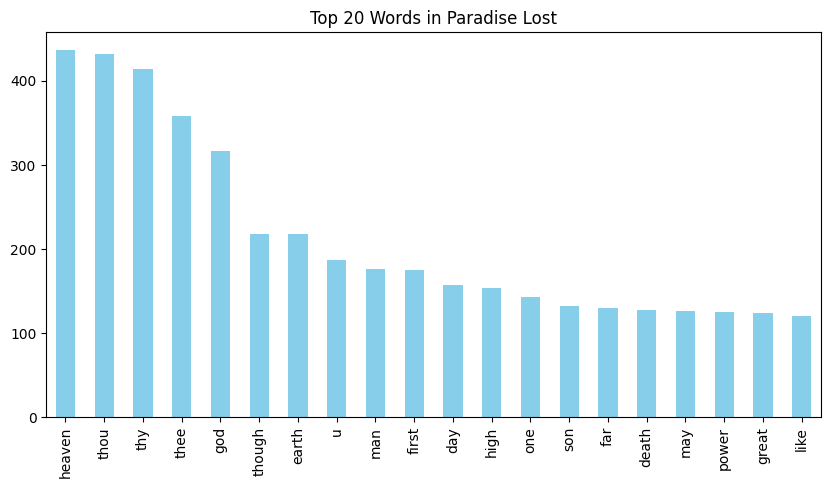

NameError: name 'sents' is not defined

In [1]:
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import string

nltk.download('gutenberg')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('punkt')

words = gutenberg.words('milton-paradise.txt')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

cleaned_words = [
    lemmatizer.lemmatize(w.lower()) 
    for w in words 
    if w.lower() not in stop_words 
    and w.lower() not in string.punctuation
    and len(w) > 1 
    and w.lower() not in ["thus", "shall", "yet"] 
]

word_counts = pd.Series(cleaned_words).value_counts()
top_20 = word_counts.head(20)

top_20.plot(kind='bar', figsize=(10,5), color='skyblue', title='Top 20 Words in Paradise Lost')
plt.show()

analyzer = SentimentIntensityAnalyzer()
sentence_data = []

for s in sents:
    sentence_text = " ".join(s)
    score = analyzer.polarity_scores(sentence_text)
    sentence_data.append({'sentence': sentence_text, 'compound': score['compound']})

df = pd.DataFrame(sentence_data)

print("--- TOP 5 POSITIVE ---")
print(df.sort_values(by='compound', ascending=False).head(5))

print("\n--- TOP 5 NEGATIVE ---")
print(df.sort_values(by='compound', ascending=True).head(5))

print("\n--- TOP 5 NEUTRAL ---")
print(df[df['compound'] == 0].head(5))


In [2]:
#I chose lemmatization because it has high accuracy. 
#Stemming is faster than lemmatization, but it can produce words like 'fli'